In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


In [2]:
DATA_PATH = 'CombinedData.csv'

if not os.path.exists(DATA_PATH):
    print(f"Error: Please upload {DATA_PATH} to the Colab files tab.")
else:
    df = pd.read_csv(DATA_PATH)
    df = df.dropna(subset=['statement', 'status']).copy()

    # Encode Labels
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(df['status'])
    num_classes = len(label_encoder.classes_)

    X_train, X_test, y_train, y_test = train_test_split(
        df['statement'].astype(str), y_encoded, test_size=0.3,
        random_state=42, stratify=y_encoded
    )

    print(f"Data ready. Classes: {label_encoder.classes_}")

    print(f"X_train shape: {X_train.shape}")
    print(f"y_train shape: {y_train.shape}")
    print(f"X_test shape: {X_test.shape}")
    print(f"y_test shape: {y_test.shape}")


Data ready. Classes: ['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress'
 'Suicidal']
X_train shape: (36876,)
y_train shape: (36876,)
X_test shape: (15805,)
y_test shape: (15805,)


In [3]:
def plot_history_json(history):
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    loss = history['loss']
    val_loss = history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training Acc')
    plt.plot(epochs, val_acc, 'go-', label='Validation Acc')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'ro-', label='Training Loss')
    plt.plot(epochs, val_loss, 'yo-', label='Validation Loss')
    plt.title('Loss')
    plt.legend()
    plt.show()

In [4]:
model_path = 'CustomNNmodel.keras'
extracted_path = 'model_extracted'

# Extract if not already done
if not os.path.exists(extracted_path):
    print("Extracting model...")
    os.makedirs(extracted_path, exist_ok=True)
    with zipfile.ZipFile(model_path, 'r') as z:
        z.extractall(extracted_path)
    print("Extraction complete.")
else:
    print("Extracted model found, skipping extraction.")

# Load config
with open(os.path.join(extracted_path, 'config.json'), 'r', encoding='utf-8') as f:
    config = json.load(f)

# Enable Lambda deserialization and reconstruct model
tf.keras.config.enable_unsafe_deserialization()
model = tf.keras.models.model_from_json(json.dumps(config))

# Load weights
model.load_weights(os.path.join(extracted_path, 'model.weights.h5'))
print("Model loaded successfully.")
print(model.summary())

# Get the vectorizer layer and rebuild its lookup table from its own weights
vectorizer = model.get_layer('vectorizer')
with open('model_extracted/assets/layers/text_vectorization/vocabulary.txt', 'r', encoding='utf-8') as f:
    vocab = [line.strip() for line in f]
vectorizer.set_vocabulary(vocab)

print(f"Vocabulary size: {len(vocab)}")
print(f"Sample tokens: {vocab[:10]}")


Extracted model found, skipping extraction.



c:\Users\awa09\OneDrive\Desktop\Custom Neural Network\.venv\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'strip_mask' (of type Lambda) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
c:\Users\awa09\OneDrive\Desktop\Custom Neural Network\.venv\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'lstm_max' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model loaded successfully.


Model: "functional_19_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_text          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vectorizer          │ (None, 256)       │          0 │ input_text[0][0]  │
│ (TextVectorization) │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 256, 128)  │  1,920,000 │ vectorizer[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 256, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_15        │ (None, 256)       │          0 │ vectorizer[0][0]  │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ strip_mask (Lambda) │ (None, 256, 128)  │          0 │ spatial_dropout[… │
│                     │                   │            │ not_equal_15[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 256, 128)  │     98,816 │ spatial_dropout[… │
│ (Bidirectional)     │                   │            │ not_equal_15[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 256, 64)   │     24,640 │ strip_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 256, 64)   │     57,408 │ strip_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_avg            │ (None, 128)       │          0 │ bidirectional_3[… │
│ (GlobalAveragePool… │                   │            │ not_equal_15[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_max            │ (None, 128)       │          0 │ bidirectional_3[… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_merge           │ (None, 256, 128)  │          0 │ conv1d_14[0][0],  │
│ (Concatenate)       │                   │            │ conv1d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 256, 128)  │     66,048 │ strip_mask[0][0], │
│ (MultiHeadAttentio… │                   │            │ strip_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_pool_merge     │ (None, 256)       │          0 │ lstm_avg[0][0],   │
│ (Concatenate)       │                   │            │ lstm_max[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_max             │ (None, 128)       │          0 │ cnn_merge[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_max            │ (None, 128)       │          0 │ multi_head_atten… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_merge        │ (None, 512)       │          0 │ lstm_pool_merge[… │
│ (Concatenate)       │                   │            │ cnn_max[0][0],    │
│                     │                   │            │ attn_max[0][0]  

 Total params: 7,097,495 (27.07 MB)

 Trainable params: 2,365,831 (9.02 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,731,664 (18.05 MB)

None
Vocabulary size: 15000
Sample tokens: ['', '[UNK]', 'i', 'to', 'and', 'the', 'my', 'a', 'it', 'of']


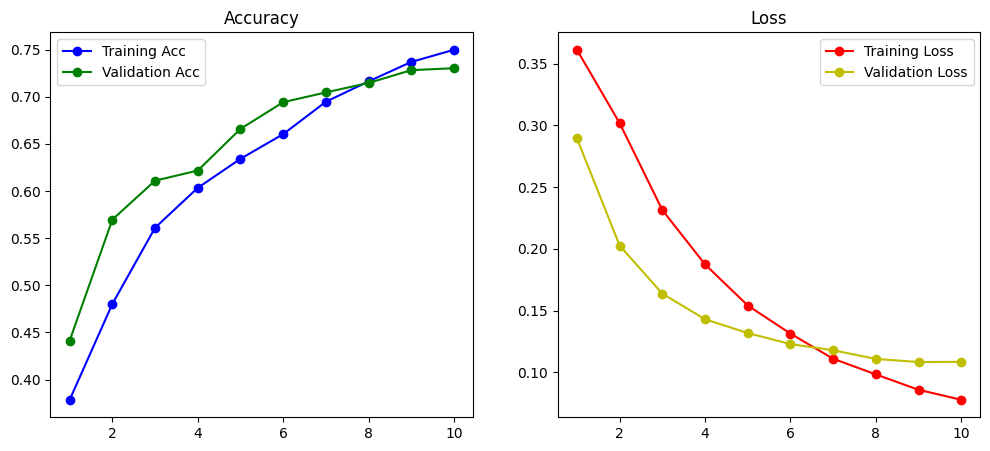

In [5]:
# Load learning history
with open('CustomNN_Learning_History.json', 'r') as f:
    history = json.load(f)

plot_history_json(history)

In [6]:
# view classification report
if os.path.exists('CustomNN_Classification_Report.json'):
    with open('CustomNN_Classification_Report.json', 'r') as f:
        report = json.load(f)
    print("Classification Report:")
    print(json.dumps(report, indent=4))

Classification Report:
{
    "Anxiety": {
        "precision": 0.7947320617620345,
        "recall": 0.7595486111111112,
        "f1-score": 0.7767421216156236,
        "support": 1152.0
    },
    "Bipolar": {
        "precision": 0.8495440729483282,
        "recall": 0.6710684273709484,
        "f1-score": 0.749832327297116,
        "support": 833.0
    },
    "Depression": {
        "precision": 0.7556291390728477,
        "recall": 0.4937256598874946,
        "f1-score": 0.5972258571054698,
        "support": 4622.0
    },
    "Normal": {
        "precision": 0.9118797611694461,
        "recall": 0.9033244952070161,
        "f1-score": 0.9075819672131148,
        "support": 4903.0
    },
    "Personality disorder": {
        "precision": 0.4538834951456311,
        "recall": 0.5789473684210527,
        "f1-score": 0.508843537414966,
        "support": 323.0
    },
    "Stress": {
        "precision": 0.41652754590984975,
        "recall": 0.6430412371134021,
        "f1-score": 0.5

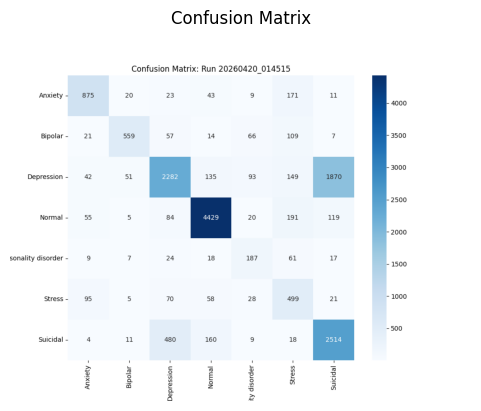

In [7]:
# view confusion matrix png 
if os.path.exists('CustomNN_Confusion_Matrix.png'):
    img = plt.imread('CustomNN_Confusion_Matrix.png')
    plt.imshow(img)
    plt.axis('off')
    plt.title('Confusion Matrix')
    plt.show()

In [8]:
def predict_statement(statement, model_to_use):
    # Ensure the statement is a string and wrap it in a list for the model input
    statement_tensor = tf.convert_to_tensor([statement], dtype=tf.string)

    # Get raw predictions (probabilities for each class)
    predictions = model_to_use.predict(statement_tensor)[0]

    print(f"Statement: '{statement}'")
    # Order of classes ['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress' 'Suicidal']
    print(f"Anxiety Confidence: {predictions[1]*100:.4f}")
    print(f"Bipolar Confidence: {predictions[2]*100:.4f}")
    print(f"Depression Confidence: {predictions[0]*100:.4f}")
    print(f"Normal Confidence: {predictions[3]*100:.4f}")
    print(f"Personality Disorder Confidence: {predictions[4]*100:.4f}")
    print(f"Stress Confidence: {predictions[5]*100:.4f}")
    print(f"Suicidal Confidence: {predictions[6]*100:.4f}")

# Example usage:
user_statement = "i've been feeling so hopeless lately and the world would be better without me but i have no plans to actually do anything about it"
predict_statement(user_statement, model)

user_statement = "work has been completely overwhelming and i can feel the tension in my shoulders and neck all day. i just can't relax even when i get home"
predict_statement(user_statement, model)

user_statement = "yesterday i felt like i was on top of the world and could do anything but today i woke up and i can't even move my life is falling apart"
predict_statement(user_statement, model)

user_statement = "i am literally dying laughing at this video it is so funny i can't breathe"
predict_statement(user_statement, model)

user_statement = "i have this constant feeling that something terrible is about to happen and i can't stop my heart from racing even though nothing is wrong"
predict_statement(user_statement, model)

# Test 1: Passive vs Active
predict_statement("i'm so done with life", model)

# Test 2: Pure Stress
predict_statement("too many deadlines i am going to snap", model)

# Test 3: The "Normal" check
predict_statement("it is a beautiful day for a walk", model)


c:\Users\awa09\OneDrive\Desktop\Custom Neural Network\.venv\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'conv1d_14' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
c:\Users\awa09\OneDrive\Desktop\Custom Neural Network\.venv\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'conv1d_15' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
c:\Users\awa09\OneDrive\Desktop\Custom Neural Network\.venv\Lib\site-packages\keras\src\layers\layer.py:1035: UserWarning: Layer 'attn_max' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore des

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
Statement: 'i've been feeling so hopeless lately and the world would be better without me but i have no plans to actually do anything about it'
Anxiety Confidence: 1.2783
Bipolar Confidence: 30.6963
Depression Confidence: 3.7150
Normal Confidence: 14.6882
Personality Disorder Confidence: 5.7302
Stress Confidence: 7.2739
Suicidal Confidence: 36.6182
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Statement: 'work has been completely overwhelming and i can feel the tension in my shoulders and neck all day. i just can't relax even when i get home'
Anxiety Confidence: 3.2852
Bipolar Confidence: 2.9095
Depression Confidence: 25.1611
Normal Confidence: 10.0741
Personality Disorder Confidence: 6.1548
Stress Confidence: 51.0776
Suicidal Confidence: 1.3377
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Statement: 'yesterday i felt like i was on top of the world and could do anything but today i woke up and i can't even move my life is falling apart'
Anxiety Confidence: 0.707